## Import Necessary Librires

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
import psutil
import time
import os

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

warnings.filterwarnings('ignore')

%matplotlib inline

## Loading Data

In [18]:
df = pd.read_csv(r'../../3_Data/processed/g_2025_hourly_all_PCA_reduced.csv')
df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,taxi_demand
0,-0.518754,0.917431,-4.289254,1.130338,-0.421782,-1.711911,2.613329,-1.037458,-1.132565,1.374478,1051
1,-0.699536,0.915800,-4.206067,1.155734,-0.421137,-1.694405,2.545232,-1.031434,-1.098232,1.314072,436
2,-0.896397,0.911873,-4.015032,0.924829,-0.424154,-1.656173,2.435000,-1.014045,-1.031267,1.189971,268
3,-1.022439,0.904980,-3.811575,0.575039,-0.437192,-1.594720,2.337239,-0.991172,-0.964198,1.051892,220
4,-1.084073,0.895503,-3.635308,0.278344,-0.456338,-1.521287,2.255461,-0.967715,-0.905209,0.920323,277


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6528 entries, 0 to 6527
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PC1          6528 non-null   float64
 1   PC2          6528 non-null   float64
 2   PC3          6528 non-null   float64
 3   PC4          6528 non-null   float64
 4   PC5          6528 non-null   float64
 5   PC6          6528 non-null   float64
 6   PC7          6528 non-null   float64
 7   PC8          6528 non-null   float64
 8   PC9          6528 non-null   float64
 9   PC10         6528 non-null   float64
 10  taxi_demand  6528 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 561.1 KB


In [20]:
df.shape

(6528, 11)

## **Splitig The Data**

In [21]:
X = df.drop(columns= ["taxi_demand",])
y = df['taxi_demand']

In [22]:
# Load and preprocess your data (X, y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
X_train.shape, X_test.shape

((5222, 10), (1306, 10))

In [24]:
y_train.shape, y_test.shape

((5222,), (1306,))

## Model Tuning

In [25]:
def memory_mb():
    return psutil.Process(os.getpid()).memory_info().rss / (1024**2)

start_time = time.time()
start_mem = memory_mb()

rf = RandomForestRegressor(random_state=42)

param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [10, 15, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False]
}

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=40,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

search.fit(X_train, y_train)
best_rf = search.best_estimator_

# Evaluation or Predictions
y_pred = best_rf.predict(X_test)

print(f"Runtime: {time.time() - start_time:.2f}s")
print(f"Memory: {memory_mb() - start_mem:.2f} MB")


Fitting 5 folds for each of 40 candidates, totalling 200 fits


[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=  11.4s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=  12.6s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=  12.8s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=  13.1s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=  13.3s
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=400; total time=  14.0s
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=400; total time=  15.4s
[CV] END bootstrap=True, max_

In [39]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
r2 = r2_score(y_test, y_pred)

print("\nModel Performance Results")
print("----------------------------")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape:.2f}%")

print("\nBest Parameters:")
print(search.best_params_)


Model Performance Results
----------------------------
RMSE : 788.7473
R2   : 0.9335
MAE  : 557.7623
MAPE : 17.74%

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30, 'bootstrap': False}


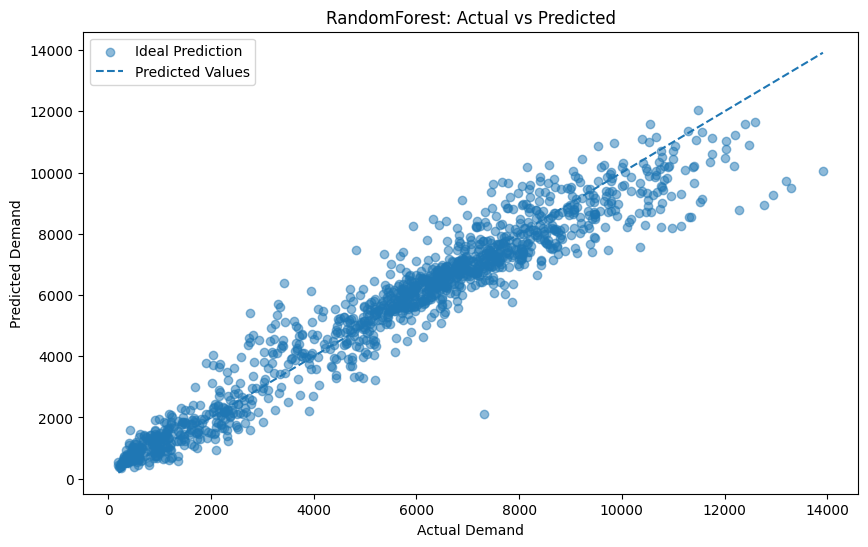

In [34]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')
plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("RandomForest: Actual vs Predicted")
plt.legend(["Ideal Prediction", "Predicted Values"])
plt.show()


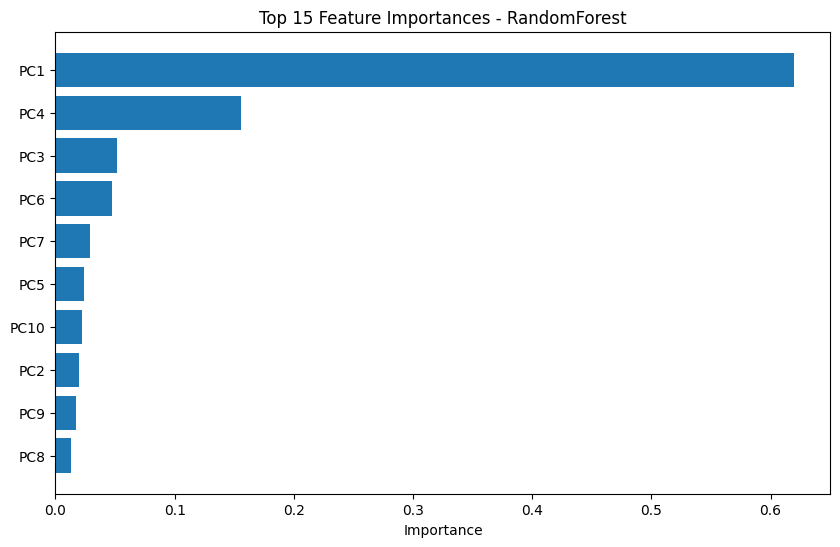

In [33]:
importance = best_rf.feature_importances_
feature_names = X_train.columns

imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False).head(15)

plt.figure(figsize=(10,6))
plt.barh(imp_df["Feature"], imp_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances - RandomForest")
plt.xlabel("Importance")
plt.show()


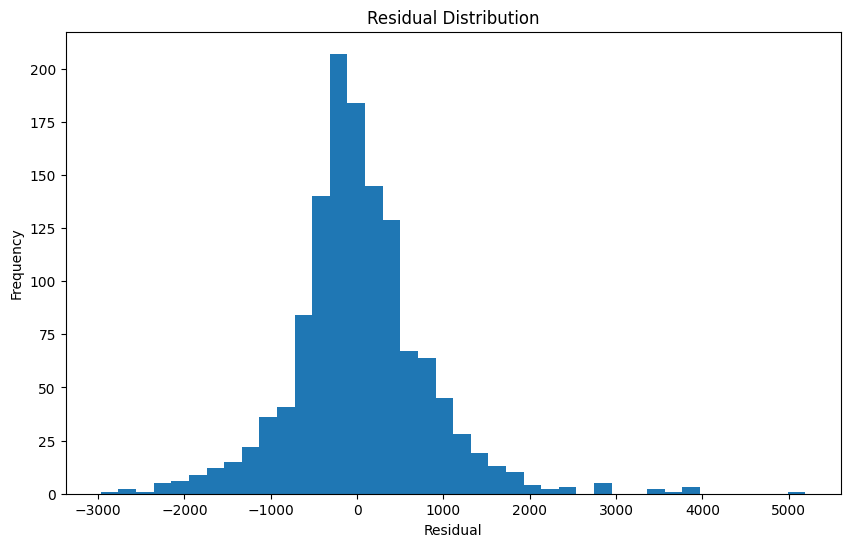

In [29]:
residuals = y_test - y_pred

plt.figure(figsize=(10,6))
plt.hist(residuals, bins=40)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()
